In [14]:
# %pip install imbalanced-learn

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import ADASYN
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [16]:
data = pd.read_csv('../../data/processed/data_selected.csv')

# Date를 날짜형으로 변환
data["Date"] = pd.to_datetime(data["Date"])

# 날짜순 정렬
data = data.sort_values("Date").reset_index(drop=True)

# 정렬 후 Date 제거
data = data.drop(columns=["Date"])

### Risk_Label을 통일하는 함수 정의

In [17]:
# Risk_Label을 0/1로 통일
# Low Risk / Low risk / low risk -> 0
# High Risk / High risk / high risk -> 1
# 이미 0/1이면 그대로 처리
    
def encode_risk_label(y_raw):
    
    if isinstance(y_raw, pd.DataFrame):
        y_raw = y_raw.iloc[:, 0]

    y_raw = y_raw.copy()

    if y_raw.dtype == object:
        y_key = (
            y_raw.astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r"[\s_\-]+", " ", regex=True)
        )

        y = y_key.map({
            "low risk": 0,
            "high risk": 1,
            "0": 0,
            "1": 1
        })
    else:
        y = pd.to_numeric(y_raw, errors="coerce")

    if y.isna().any():
        print("변환 실패한 라벨:")
        print(y_raw[y.isna()].unique())
        raise ValueError("Risk_Label에 0/1로 변환되지 않은 값이 있음")

    return y.astype(int).reset_index(drop=True)

### 데이터 분할

In [18]:
# train:valid:test 45:35:20
data_train = data[:int(len(data) * 0.45)].copy()
data_valid = data[int(len(data) * 0.45):int(len(data) * 0.8)].copy()
data_test = data[int(len(data) * 0.8):].copy()

# 분할 직후 Risk_Label 인코딩
data_train["Risk_Label"] = encode_risk_label(data_train["Risk_Label"]).values
data_valid["Risk_Label"] = encode_risk_label(data_valid["Risk_Label"]).values
data_test["Risk_Label"] = encode_risk_label(data_test["Risk_Label"]).values

drop_cols = ["Risk_Label"]

X_train = data_train.drop(columns=drop_cols, errors="ignore")
y_train = data_train["Risk_Label"].astype(int)

X_valid = data_valid.drop(columns=drop_cols, errors="ignore")
y_valid = data_valid["Risk_Label"].astype(int)

X_test = data_test.drop(columns=drop_cols, errors="ignore")
y_test = data_test["Risk_Label"].astype(int)

label_name_map = {0: "LowRisk", 1: "HighRisk"}

print("train/valid/test:", len(data_train), len(data_valid), len(data_test))
print("y_train class:", y_train.map(label_name_map).value_counts().to_dict())

train/valid/test: 1848 1438 822
y_train class: {'LowRisk': 1665, 'HighRisk': 183}


### Min-Max Scaling

In [19]:
scaler = MinMaxScaler().set_output(transform="pandas")

# train에만 fit하고 valid/test에는 같은 scaler 적용
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

print("train/valid/test:", len(data_train), len(data_valid), len(data_test))
print("y_train class:", y_train.value_counts().sort_index().to_dict())

train/valid/test: 1848 1438 822
y_train class: {0: 1665, 1: 183}


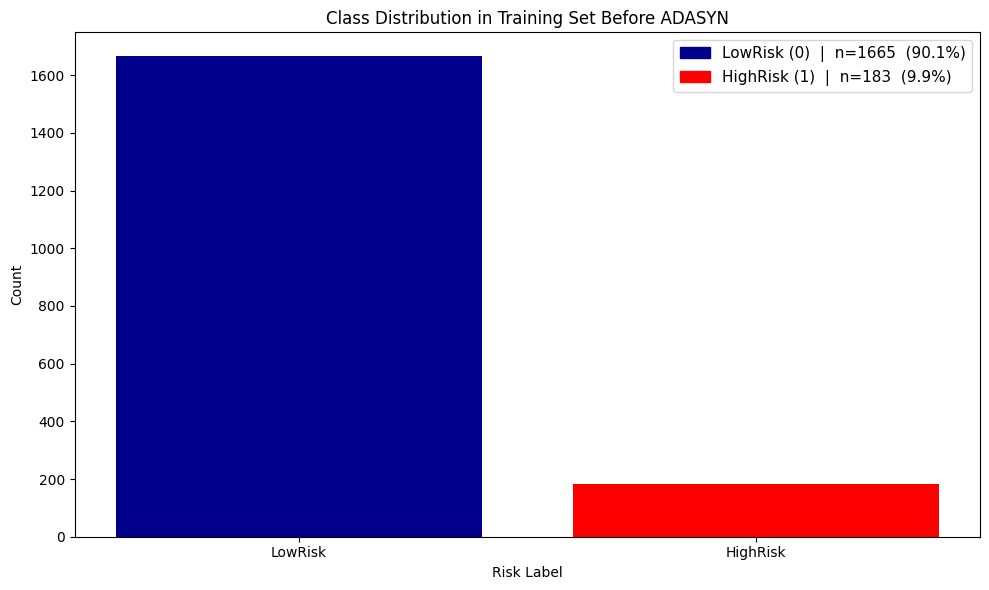

In [20]:
# 클래스 불균형 확인: train set 기준
counts = y_train.value_counts().sort_index()
label_name_map = {0: "LowRisk", 1: "HighRisk"}
colors = {0: "darkblue", 1: "red"}
total = counts.sum()

x_labels = [label_name_map.get(idx, str(idx)) for idx in counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    x_labels,
    counts.values,
    color=[colors.get(k, "grey") for k in counts.index]
)

legend_labels = [
    f"{label_name_map.get(idx, idx)} ({idx})  |  n={cnt}  ({cnt/total*100:.1f}%)"
    for idx, cnt in zip(counts.index, counts.values)
]

legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=colors.get(idx, "grey"))
    for idx in counts.index
]

ax.legend(legend_patches, legend_labels, fontsize=11)
ax.set_xlabel("Risk Label")
ax.set_ylabel("Count")
ax.set_title("Class Distribution in Training Set Before ADASYN")
plt.tight_layout()
plt.show()

In [21]:
sampling_strategy_list = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
n_neighbors_list = [3, 5, 7]

RF_FIXED_PARAMS = {
    "n_estimators": 500,
    "max_depth": None,
    "min_samples_leaf": 5,
    "min_samples_split": 2,
    "max_features": "sqrt",
    "class_weight": None,
    "random_state": 1,
    "n_jobs": -1
}

# valid를 65:35으로 반반 분할
valid_ratio = int(len(X_valid_scaled) * 0.65)

X_valid_cutoff = X_valid_scaled.iloc[:valid_ratio].copy()
y_valid_cutoff = y_valid.iloc[:valid_ratio].copy()

X_valid_eval = X_valid_scaled.iloc[valid_ratio:].copy()
y_valid_eval = y_valid.iloc[valid_ratio:].copy()

thresholds = np.arange(0.01, 0.81, 0.01)

def get_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    gmean = np.sqrt(recall * specificity)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "GMean": gmean,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    }

results = []

for ratio in sampling_strategy_list:
    for k in n_neighbors_list:
        try:
            adasyn = ADASYN(
                sampling_strategy=ratio,
                n_neighbors=k,
                random_state=1
            )

            X_res, y_res = adasyn.fit_resample(X_train_scaled, y_train)

            X_res = X_res.copy().reset_index(drop=True)
            y_res = pd.Series(y_res).astype(int).reset_index(drop=True)

            # Signal 더미변수 반올림
            dummy_cols = [
                col for col in X_res.columns
                if col.startswith("Signal") and (col.endswith("_Buy") or col.endswith("_Sell"))
            ]
            X_res[dummy_cols] = X_res[dummy_cols].round().astype(int)

            rf = RandomForestClassifier(**RF_FIXED_PARAMS)
            rf.fit(X_res, y_res)

            # 1) valid 앞 절반에서 cutoff 선택
            y_cutoff_prob = rf.predict_proba(X_valid_cutoff)[:, 1]

            best_cutoff = None
            best_cutoff_gmean = -1
            best_cutoff_metrics = None

            for cutoff in thresholds:
                y_cutoff_pred = (y_cutoff_prob >= cutoff).astype(int)
                cutoff_metrics = get_metrics(y_valid_cutoff, y_cutoff_pred)

                if cutoff_metrics["GMean"] > best_cutoff_gmean:
                    best_cutoff_gmean = cutoff_metrics["GMean"]
                    best_cutoff = cutoff
                    best_cutoff_metrics = cutoff_metrics

            # 2) valid 뒤 절반에서 성능 평가
            y_eval_prob = rf.predict_proba(X_valid_eval)[:, 1]
            y_eval_pred = (y_eval_prob >= best_cutoff).astype(int)

            eval_metrics = get_metrics(y_valid_eval, y_eval_pred)

            eval_metrics.update({
                "sampling_strategy": ratio,
                "n_neighbors": k,
                "best_cutoff": best_cutoff,
                "cutoff_GMean": best_cutoff_metrics["GMean"],
                "cutoff_F1": best_cutoff_metrics["F1"],
                "cutoff_Recall": best_cutoff_metrics["Recall"],
                "cutoff_Specificity": best_cutoff_metrics["Specificity"],
                "resampled_LowRisk": int((y_res == 0).sum()),
                "resampled_HighRisk": int((y_res == 1).sum())
            })

            results.append(eval_metrics)

        except Exception as e:
            results.append({
                "sampling_strategy": ratio,
                "n_neighbors": k,
                "error": str(e)
            })

search_df = pd.DataFrame(results)

if "error" in search_df.columns:
    search_df_valid = search_df[search_df["error"].isna()].copy()
else:
    search_df_valid = search_df.copy()

search_df_valid = search_df_valid.sort_values(
    by=["GMean", "F1", "Recall"],
    ascending=False
).reset_index(drop=True)

if "Rank" in search_df_valid.columns:
    search_df_valid = search_df_valid.drop(columns=["Rank"])

search_df_valid.insert(0, "Rank", range(1, len(search_df_valid) + 1))

display_cols = [
    "Rank",
    "sampling_strategy",
    "n_neighbors",
    "best_cutoff",
    "resampled_LowRisk",
    "resampled_HighRisk",
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "GMean",
    "TN", "FP", "FN", "TP",
    "cutoff_GMean",
    "cutoff_F1",
    "cutoff_Recall",
    "cutoff_Specificity"
]

display(search_df_valid[display_cols])

best_row = search_df_valid.iloc[0]

best_sampling_strategy = best_row["sampling_strategy"]
best_n_neighbors = int(best_row["n_neighbors"])
best_rf_cutoff = best_row["best_cutoff"]

print("Best sampling_strategy:", best_sampling_strategy)
print("Best n_neighbors:", best_n_neighbors)
print("Best RF cutoff:", best_rf_cutoff)
print("Validation-eval GMean:", best_row["GMean"])
print("Validation-eval F1:", best_row["F1"])
print("Validation-eval Recall:", best_row["Recall"])
print("Validation-eval Specificity:", best_row["Specificity"])

,Rank,sampling_strategy,n_neighbors,best_cutoff,resampled_LowRisk,resampled_HighRisk,Accuracy,Precision,Recall,Specificity,F1,GMean,TN,FP,FN,TP,cutoff_GMean,cutoff_F1,cutoff_Recall,cutoff_Specificity
0,1,0.5,7,0.24,1665,821,0.565476,0.216730,0.814286,0.525346,0.342342,0.654050,228,206,13,57,0.674344,0.305630,0.619565,0.733967
1,2,0.3,5,0.19,1665,497,0.567460,0.210938,0.771429,0.534562,0.331288,0.642166,232,202,16,54,0.689058,0.314961,0.652174,0.728029
2,3,0.3,7,0.19,1665,520,0.555556,0.208333,0.785714,0.518433,0.329341,0.638232,225,209,15,55,0.694777,0.319372,0.663043,0.728029
3,4,0.7,5,0.27,1665,1180,0.553571,0.205323,0.771429,0.518433,0.324324,0.632403,225,209,16,54,0.675444,0.299492,0.641304,0.711401
4,5,0.7,7,0.27,1665,1232,0.545635,0.204461,0.785714,0.506912,0.324484,0.631101,220,214,15,55,0.678866,0.300752,0.652174,0.706651
5,6,0.2,5,0.14,1665,352,0.535714,0.202899,0.800000,0.493088,0.323699,0.628069,214,220,14,56,0.699425,0.312500,0.706522,0.692399
6,7,0.6,5,0.24,1665,925,0.545635,0.200000,0.757143,0.511521,0.316418,0.622330,222,212,17,53,0.657498,0.285714,0.608696,0.710214
7,8,1.0,3,0.27,1665,1668,0.537698,0.199262,0.771429,0.500000,0.316716,0.621059,217,217,16,54,0.676580,0.297767,0.652174,0.701900
8,9,0.3,3,0.16,1665,470,0.525794,0.199288,0.800000,0.481567,0.319088,0.620688,209,225,14,56,0.694005,0.305882,0.706522,0.681710
9,10,0.4,5,0.19,1665,670,0.519841,0.199301,0.814286,0.472350,0.320225,0.620184,205,229,13,57,0.687398,0.302885,0.684783,0.690024


Best sampling_strategy: 0.5
Best n_neighbors: 7
Best RF cutoff: 0.24000000000000002
Validation-eval GMean: 0.6540500249634633
Validation-eval F1: 0.34234234234234234
Validation-eval Recall: 0.8142857142857143
Validation-eval Specificity: 0.5253456221198156


### **ADA**ptive **SYN**

### Train data에 ADASYN 적용

In [22]:
# =========================
# train 데이터에만 ADASYN 적용
# =========================

X = X_train_scaled.copy().reset_index(drop=True)
y = y_train.copy().reset_index(drop=True)

adasyn = ADASYN(
    sampling_strategy=best_sampling_strategy,
    n_neighbors=best_n_neighbors,
    random_state=1
)

X_resampled, y_resampled = adasyn.fit_resample(X, y)

data_train_adasyn = X_resampled.copy().reset_index(drop=True)
data_train_adasyn["Risk_Label"] = pd.Series(y_resampled).astype(int).reset_index(drop=True)

# ADASYN 후 Signal 더미변수 반올림
dummy_cols = [
    col for col in data_train_adasyn.columns
    if col.startswith("Signal")
]

data_train_adasyn[dummy_cols] = (
    data_train_adasyn[dummy_cols]
    .round()
    .astype(int)
)

# Signal 더미변수 검증
for col in dummy_cols:
    bad_count = (~data_train_adasyn[col].isin([0, 1])).sum()
    assert bad_count == 0, f"{col}에 0/1 외 값이 남아 있음: {bad_count}개"

print("ADASYN 후 class 분포:")
print(data_train_adasyn["Risk_Label"].value_counts().sort_index())
print("✓ Signal 더미변수 0/1 반올림 완료")

ADASYN 후 class 분포:
Risk_Label
0    1665
1     821
Name: count, dtype: int64
✓ Signal 더미변수 0/1 반올림 완료


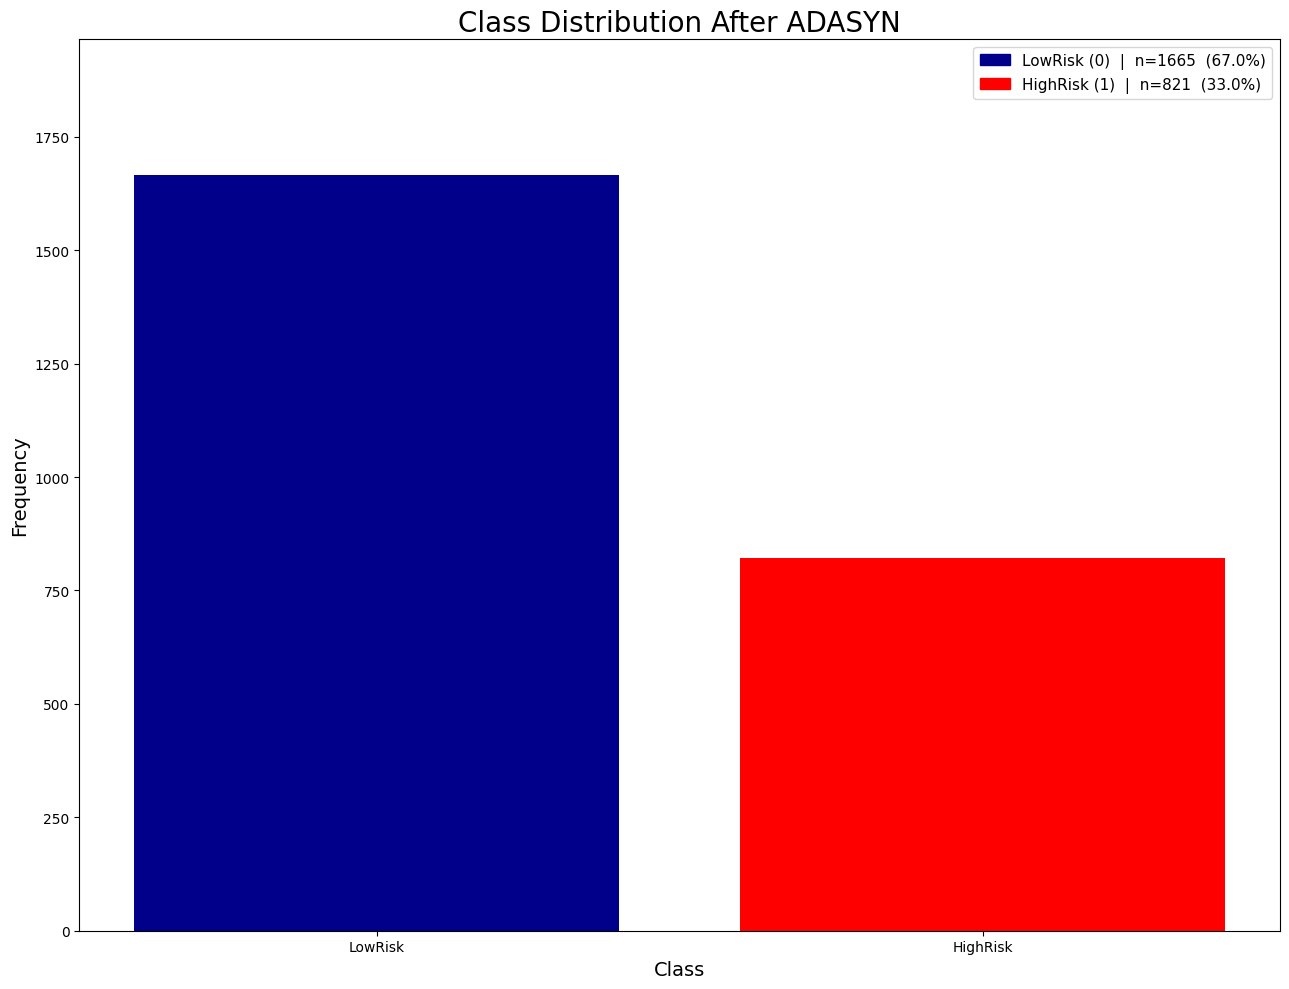

In [23]:
# 3. ADASYN 적용 후 클래스 분포 확인
counts = pd.Series(y_resampled).value_counts().sort_index()
label_name_map = {0: 'LowRisk', 1: 'HighRisk'}
colors = {0: 'darkblue', 1: 'red'}
total = counts.sum()

x_labels = [label_name_map.get(int(idx), str(idx)) for idx in counts.index]

fig, ax = plt.subplots(figsize=(13, 10))
ax.bar(
    x_labels,
    counts.values,
    color=[colors.get(int(k), 'grey') for k in counts.index]
)

# legend에 이름, index, count, 비율 표시
legend_labels = [
    f"{label_name_map.get(int(idx), idx)} ({int(idx)})  |  n={cnt}  ({cnt/total*100:.1f}%)"
    for idx, cnt in zip(counts.index, counts.values)
]
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=colors.get(int(idx), 'grey'))
    for idx in counts.index
]
ax.legend(legend_patches, legend_labels, fontsize=11)

ax.set_xlabel('Class', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.set_title('Class Distribution After ADASYN', fontsize=20)
plt.ylim(0, max(counts.values) * 1.18)
plt.tight_layout()
plt.show()

In [24]:
# ======= [저장 직전 최종 검증] =======

data_valid_scaled = X_valid_scaled.copy().reset_index(drop=True)
data_valid_scaled["Risk_Label"] = y_valid.reset_index(drop=True).astype(int)

data_test_scaled = X_test_scaled.copy().reset_index(drop=True)
data_test_scaled["Risk_Label"] = y_test.reset_index(drop=True).astype(int)

# 컬럼 순서 검증
assert list(data_train_adasyn.drop(columns="Risk_Label").columns) == list(data_valid_scaled.drop(columns="Risk_Label").columns)
assert list(data_train_adasyn.drop(columns="Risk_Label").columns) == list(data_test_scaled.drop(columns="Risk_Label").columns)

print("=== Risk_Label 분포 검증 ===")
print(f"[train ADASYN] {data_train_adasyn['Risk_Label'].value_counts().sort_index().to_dict()}")
print(f"[valid]        {data_valid_scaled['Risk_Label'].value_counts().sort_index().to_dict()}")
print(f"[test]         {data_test_scaled['Risk_Label'].value_counts().sort_index().to_dict()}")

for name, df in [
    ("train_adasyn", data_train_adasyn),
    ("valid", data_valid_scaled),
    ("test", data_test_scaled)
]:
    bad = set(df["Risk_Label"].unique()) - {0, 1}
    assert not bad, f"[{name}] 이상한 Risk_Label 값 발견: {bad}"

print("✓ 모든 Risk_Label 정상")
print("✓ train/valid/test 컬럼 순서 동일")

=== Risk_Label 분포 검증 ===
[train ADASYN] {0: 1665, 1: 821}
[valid]        {0: 1276, 1: 162}
[test]         {0: 731, 1: 91}
✓ 모든 Risk_Label 정상
✓ train/valid/test 컬럼 순서 동일


In [25]:
# 5. CSV로 저장
data_train_adasyn.to_csv('../../data/processed/ADASYN/data_train_adasyn.csv', index=False)
data_valid_scaled.to_csv('../../data/processed/ADASYN/data_valid.csv', index=False)
data_test_scaled.to_csv('../../data/processed/ADASYN/data_test.csv', index=False)